In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv


# Olist Marketplace Intelligence Platform
### End-to-End Marketplace Analytics, Experimentation, Forecasting, and Machine Learning System for E-Commerce Decision Making

### Business Problem
Executive Question

Olist is a Brazilian marketplace connecting thousands of sellers and customers.

Leadership wants to understand:

Is the marketplace growing?
What drives customer satisfaction?
Are delivery delays hurting business outcomes?
Which customers are likely to become loyal customers?
Which sellers are at risk?
What revenue can be expected in the future?
Which operational changes should be prioritized?

In [2]:
import warnings
warnings.filterwarnings('ignore')
 
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 150)

## Step 1: Data Loading

In [3]:
INPUT_PATH = '/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/'
OUTPUT_PATH = '/kaggle/working/'

In [4]:
orders = pd.read_csv(INPUT_PATH + 'olist_orders_dataset.csv')
order_items = pd.read_csv(INPUT_PATH + 'olist_order_items_dataset.csv')
order_payments = pd.read_csv(INPUT_PATH + 'olist_order_payments_dataset.csv')
order_reviews = pd.read_csv(INPUT_PATH + 'olist_order_reviews_dataset.csv')
customers = pd.read_csv(INPUT_PATH + 'olist_customers_dataset.csv')
products = pd.read_csv(INPUT_PATH + 'olist_products_dataset.csv')
sellers = pd.read_csv(INPUT_PATH + 'olist_sellers_dataset.csv')
geolocation = pd.read_csv(INPUT_PATH + 'olist_geolocation_dataset.csv')
category_translation = pd.read_csv(INPUT_PATH + 'product_category_name_translation.csv')

In [5]:
tables = {
    'orders': orders, 
    'order_items': order_items, 
    'order_payments': order_payments,
    'order_reviews': order_reviews, 
    'customers': customers, 
    'products': products,
    'sellers': sellers, 
    'geolocation': geolocation,
    'category_translation': category_translation
}

In [6]:
print("Table shapes:")
for name, t in tables.items():
    print(f"  {name:25s} {t.shape[0]:>16,} rows  x  {t.shape[1]} cols")

Table shapes:
  orders                              99,441 rows  x  8 cols
  order_items                        112,650 rows  x  7 cols
  order_payments                     103,886 rows  x  5 cols
  order_reviews                       99,224 rows  x  7 cols
  customers                           99,441 rows  x  5 cols
  products                            32,951 rows  x  9 cols
  sellers                              3,095 rows  x  4 cols
  geolocation                      1,000,163 rows  x  5 cols
  category_translation                    71 rows  x  2 cols


We found that the geolocation is the largest table as it has many rows 

 ## Step 2: Initial Data Quality Audit

In [7]:
print("=" * 60)
print("MISSING VALUES — BEFORE CLEANING")
print("=" * 60)
for name, t in tables.items():
    missing = t.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\n{name}:")
        for col, n_missing in missing.items():
            pct = 100 * n_missing / len(t)
            print(f"  {col:35s} {n_missing:>7,} missing ({pct:.2f}%)")
 
print("=" * 60)
print("DUPLICATE ROWS — BEFORE CLEANING")
print("=" * 60)
for name, t in tables.items():
    n_dupes = t.duplicated().sum()
    print(f"  {name:25s} {n_dupes:>5,} exact duplicate rows")

MISSING VALUES — BEFORE CLEANING

orders:
  order_approved_at                       160 missing (0.16%)
  order_delivered_carrier_date          1,783 missing (1.79%)
  order_delivered_customer_date         2,965 missing (2.98%)

order_reviews:
  review_comment_title                 87,656 missing (88.34%)
  review_comment_message               58,247 missing (58.70%)

products:
  product_category_name                   610 missing (1.85%)
  product_name_lenght                     610 missing (1.85%)
  product_description_lenght              610 missing (1.85%)
  product_photos_qty                      610 missing (1.85%)
  product_weight_g                          2 missing (0.01%)
  product_length_cm                         2 missing (0.01%)
  product_height_cm                         2 missing (0.01%)
  product_width_cm                          2 missing (0.01%)
DUPLICATE ROWS — BEFORE CLEANING
  orders                        0 exact duplicate rows
  order_items                   0 e

## Step 3: Missingness Investigation

In [8]:
print(orders[orders['order_delivered_customer_date'].isnull()]['order_status'].value_counts())

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64


### Data Quality Finding: Distinguishing Informative Missingness from Data Defects

A missing value should not automatically be treated as a data-quality problem. To understand the missing `order_delivered_customer_date` values, we analyzed the distribution of `order_status` among all orders with a null delivery timestamp.

Of the 2,965 orders with a missing delivery date, 2,957 belonged to statuses such as `shipped`, `canceled`, `unavailable`, `processing`, `approved`, and `created`. In these cases, the customer had not yet received the order (or would never receive it), making the absence of a delivery date expected. This represents **informative missingness**, where the missing value itself conveys operational information about the order lifecycle.

However, 8 orders were marked as `delivered` while simultaneously lacking a recorded delivery timestamp. Because a delivered order should always have an associated delivery date, these records represent a genuine data-quality defect rather than informative missingness.

Although these defects account for only 0.008% of all orders and are too small to materially affect marketplace KPIs, they were explicitly flagged through a `delivery_date_missing_flag` variable and tracked throughout the data pipeline. This ensures transparency in downstream analyses and prevents data-quality issues from being silently absorbed into routine missing-value handling.

This distinction is particularly important because delivery-based metrics—including delivery duration, on-time delivery rate, and the fast-versus-slow delivery cohorts used in later experimentation analyses—depend directly on the integrity of delivery timestamps.


In [9]:
delivered_no_date = orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_delivered_customer_date'].isnull())
]
print(f"Data quality defect: {len(delivered_no_date)} orders marked 'delivered' "
      f"with no delivery date logged.")
print(f"This is {100*len(delivered_no_date)/len(orders):.3f}% of all orders — "
      f"too small to bias results, but documented and excluded from delivery-time "
      f"calculations rather than silently dropped.")

Data quality defect: 8 orders marked 'delivered' with no delivery date logged.
This is 0.008% of all orders — too small to bias results, but documented and excluded from delivery-time calculations rather than silently dropped.


In [10]:
# Tag these explicitly so they're traceable through the rest of the pipeline
orders['delivery_date_missing_flag'] = (
    (orders['order_status'] == 'delivered') &
    (orders['order_delivered_customer_date'].isnull()))

In [11]:
cols_check = ['product_category_name', 'product_name_lenght',
              'product_description_lenght', 'product_photos_qty']
same_rows = products[cols_check].isnull().all(axis=1).sum()
print(f"Products missing all 4 descriptive fields together: {same_rows:,} "
      f"(out of {products['product_category_name'].isnull().sum():,} missing category_name)")

Products missing all 4 descriptive fields together: 610 (out of 610 missing category_name)


In [12]:
products['product_category_name'] = (products['product_category_name'].fillna('unknown_category'))

### Data Quality Finding: Product Catalog Completeness Issue

The product catalog initially appeared to have four separate missing-value issues because `product_category_name`, `product_description_lenght`, `product_name_lenght`, and `product_photos_qty` each contained exactly 610 missing values. To determine whether these represented independent data-quality problems or a single underlying issue, I verified the overlap of missing records across all four fields.

The investigation showed that all 610 missing values occurred in the exact same set of products. Every product missing a category name was also missing its description length, title length, and photo count. This indicates a **catalog completeness issue** affecting a subset of products rather than four independent missing-value problems.

Because the missingness is perfectly clustered within the same products, it is unlikely to be random. Instead, it suggests that these products were incompletely registered in the marketplace catalog, potentially due to listing failures, partial seller submissions, or catalog ingestion issues.

To preserve transactional information while maintaining transparency, these products were retained in the dataset and assigned the label `unknown_category` rather than being removed. This approach ensures that revenue, order counts, and customer behavior associated with these products remain available for analysis while explicitly identifying them as incompletely described catalog entries.


## Step 4: Datetime Conversion

In [13]:
order_date_cols = [ 'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date']
for col in order_date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')
 
review_date_cols = ['review_creation_date', 'review_answer_timestamp']
for col in review_date_cols:
    order_reviews[col] = pd.to_datetime(order_reviews[col], errors='coerce')
 
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'], errors='coerce')
 
print("Datetime conversion complete.")
print(orders[order_date_cols].dtypes)

Datetime conversion complete.
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


## Step 5: Deduplication 

### **order_reviews**: 
The audit in Step 2 showed 0 exact duplicate rows for this table on this run — so there is nothing to remove here. We still run the dedup logic below as a defensive check (it's a no-op if there's truly nothing duplicated), because relying on "I assumed it was clean" rather than "I checked and confirmed it's clean" is exactly the gap we're trying to avoid elsewhere in this notebook. If a future version of this dataset, or a different export, does contain duplicate reviews, this step will catch it instead of silently inflating order-review counts downstream.  

In [14]:
 order_reviews.columns

Index(['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp'], dtype='object')

In [15]:
before = len(order_reviews)
order_reviews = order_reviews.drop_duplicates(
    subset=['order_id', 'review_score', 'review_creation_date'], keep='first'
)
after = len(order_reviews)
print(f"order_reviews: removed {before - after:,} duplicate rows ({before:,} -> {after:,})")
if before == after:
    print("-> Confirms the Step 2 finding: order_reviews had 0 duplicates to begin with.")

order_reviews: removed 126 duplicate rows (99,224 -> 99,098)


In [16]:
order_reviews = order_reviews.sort_values('review_answer_timestamp').drop_duplicates(
    subset='order_id', keep='last'
)
print(f"order_reviews after enforcing 1-review-per-order: {len(order_reviews):,} rows")

order_reviews after enforcing 1-review-per-order: 98,673 rows


## Step 6: Geolocation Cleaning

In [17]:
geolocation.columns

Index(['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state'], dtype='object')

In [24]:
numeric_cols = geolocation.select_dtypes(include=['number'])
print(numeric_cols.skew())

geolocation_zip_code_prefix    0.694494
geolocation_lat                1.565147
geolocation_lng               -0.102417
dtype: float64


In [25]:
print(f"geolocation: {len(geolocation):,} raw rows, "
      f"{geolocation['geolocation_zip_code_prefix'].nunique():,} unique zip prefixes")
 
geolocation_clean = geolocation.groupby('geolocation_zip_code_prefix').agg(
    geo_lat=('geolocation_lat', 'median'),
    geo_lng=('geolocation_lng', 'median'),
    geo_city=('geolocation_city', 'first'),
    geo_state=('geolocation_state', 'first')
).reset_index()
 
print(f"geolocation_clean: {len(geolocation_clean):,} rows (one per zip prefix)")

geolocation: 1,000,163 raw rows, 19,015 unique zip prefixes
geolocation_clean: 19,015 rows (one per zip prefix)


**Critical data quality issue:** `customer_id` in this dataset is generated fresh every time a person places an order. `customer_unique_id` is the actual person. If we compute repeat-purchase rate using `customer_id`, every customer will look like a one-time buyer (because customer_id only ever appears once per order, by construction).

 We verify this explicitly below, then make sure every downstream join and customer-level aggregation uses `customer_unique_id`.

In [26]:
n_customer_id = customers['customer_id'].nunique()
n_customer_unique_id = customers['customer_unique_id'].nunique()
n_orders = orders['order_id'].nunique()
 
print(f"Unique customer_id:         {n_customer_id:,}")
print(f"Unique customer_unique_id:  {n_customer_unique_id:,}")
print(f"Unique order_id:            {n_orders:,}")
print(f"\n-> customer_id count ({n_customer_id:,}) matches order count ({n_orders:,}):",
      n_customer_id == n_orders)
print("-> This confirms customer_id is order-scoped, not person-scoped.")
print(f"-> The TRUE number of unique people is {n_customer_unique_id:,}, "
      f"which is {100*(1 - n_customer_unique_id/n_customer_id):.1f}% fewer "
      f"than the customer_id count.")

Unique customer_id:         99,441
Unique customer_unique_id:  96,096
Unique order_id:            99,441

-> customer_id count (99,441) matches order count (99,441): True
-> This confirms customer_id is order-scoped, not person-scoped.
-> The TRUE number of unique people is 96,096, which is 3.4% fewer than the customer_id count.


In [27]:
orders.duplicated().sum()

np.int64(0)

In [28]:
orders.duplicated(subset=['order_id']).sum()

np.int64(0)

In [29]:
orders.duplicated(subset=['order_id', 'customer_id']).sum()

np.int64(0)

In [30]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_date_missing_flag'],
      dtype='object')

# Product Category Translation

In [31]:
products.columns.tolist()

['product_id',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm']

In [32]:
products = products.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

## Step 7: Master Table Creation

In [33]:
master = order_items.merge(
    orders,
    on='order_id',
    how='left'
)

master = master.merge(
    customers,
    on='customer_id',
    how='left'
)

master = master.merge(
    products[
        [
            'product_id',
            'product_category_name_english',
            'product_weight_g',
            'product_length_cm',
            'product_height_cm',
            'product_width_cm'
        ]
    ],
    on='product_id',
    how='left'
)

master = master.merge(
    sellers,
    on='seller_id',
    how='left'
)

master = master.merge(
    order_reviews[
        [
            'order_id',
            'review_score',
            'review_creation_date',
            'review_answer_timestamp'
        ]
    ],
    on='order_id',
    how='left'
)

In [34]:
print(master.shape)

print(master['order_id'].nunique())

print(master['customer_unique_id'].nunique())

(112650, 30)
98666
95420


In [35]:
print(master['review_score'].isnull().mean()*100)

print(master['product_id'].isnull().sum())

print(master['seller_id'].isnull().sum())

print(master['customer_unique_id'].isnull().sum())

0.8362183754993343
0
0
0


# Payment Aggregation & Merge

In [37]:
order_payments.columns

Index(['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value'], dtype='object')

In [38]:
payments_agg = (order_payments.groupby('order_id').agg(
        total_payment_value=('payment_value', 'sum'),
        payment_installments_max=('payment_installments', 'max'),
        payment_type_primary=('payment_type',
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
        )
    ).reset_index()
)

In [39]:
master = master.merge(
    payments_agg,
    on='order_id',
    how='left'
)

In [40]:
print(master.shape)

print(master['order_id'].nunique())

(112650, 33)
98666


In [41]:
master.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'customer_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'delivery_date_missing_flag', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'product_category_name_english', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state', 'review_score', 'review_creation_date', 'review_answer_timestamp',
       'total_payment_value', 'payment_installments_max', 'payment_type_primary'],
      dtype='object')

## Step 8: Feature Engineering — Delivery Lifecycle Analysis


### Approval Latency

In [42]:
master['approval_latency_days'] = (master['order_approved_at']- master['order_purchase_timestamp']).dt.total_seconds() / 86400

### Carrier Handoff Time

In [43]:
master['carrier_handoff_days'] = (master['order_delivered_carrier_date']- master['order_approved_at']).dt.total_seconds() / 86400

### Carrier Transit Time  

In [44]:
master['carrier_transit_days'] = (master['order_delivered_customer_date']- master['order_delivered_carrier_date']).dt.total_seconds() / 86400

### Total Delivery Time  

In [45]:
master['delivery_days'] = (master['order_delivered_customer_date']- master['order_purchase_timestamp']).dt.total_seconds() / 86400

### Delivery Promise Gap

In [46]:
master['delivery_promise_gap_days'] = (
    master['order_delivered_customer_date']
    - master['order_estimated_delivery_date']
).dt.total_seconds() / 86400

### On-Time Delivery Flag

In [47]:
master['on_time_delivery'] = (master['delivery_promise_gap_days'] <= 0)

### Fast vs Slow Delivery Group

### Why Are We Evaluating the Median?

The fast-versus-slow delivery split will later be used as the treatment/control group in our experimentation notebooks. Before choosing a threshold, we need  to understand the distribution of delivery times.

If delivery times are approximately symmetric, the mean and median should be similar. If the distribution contains a long tail of extremely late deliveries,
the mean may be pulled upward by outliers, making the median a more robust measure of the typical delivery experience.

We therefore inspect the distribution before selecting the split criterion.

In [48]:
master['delivery_days'].describe()

count    110196.000000
mean         12.472631
std           9.445655
min           0.533414
25%           6.736262
50%          10.184282
75%          15.541097
max         209.628611
Name: delivery_days, dtype: float64

In [49]:
master['delivery_days'].skew()

np.float64(3.8392523909847434)

In [50]:
master['delivery_days'].quantile( [0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

0.25     6.736262
0.50    10.184282
0.75    15.541097
0.90    22.921071
0.95    29.058967
0.99    45.805398
Name: delivery_days, dtype: float64

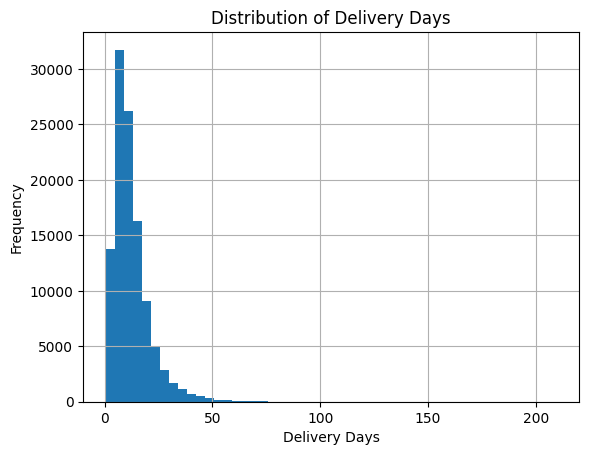

In [51]:
import matplotlib.pyplot as plt

master['delivery_days'].hist(bins=50)

plt.title('Distribution of Delivery Days')
plt.xlabel('Delivery Days')
plt.ylabel('Frequency')
plt.show()

The distribution of delivery times was inspected using summary statistics, quantiles, skewness, and a histogram. Delivery times exhibited a long right tail, with the mean substantially exceeding the median and a positive skewness
coefficient. Because a small number of extreme delays disproportionately influenced the mean, the median was selected as the threshold for defining fast and slow delivery groups.

In [52]:
median_delivery = master['delivery_days'].median()

master['delivery_speed_group'] = np.where(
    master['delivery_days'] <= median_delivery,
    'fast',
    'slow'
)

master.loc[master['delivery_days'].isnull(),'delivery_speed_group'] = np.nan

In [53]:
print(master[
    [
        'approval_latency_days',
        'carrier_handoff_days',
        'carrier_transit_days',
        'delivery_days',
        'delivery_promise_gap_days'
    ]
].describe())

       approval_latency_days  carrier_handoff_days  carrier_transit_days  delivery_days  delivery_promise_gap_days
count          112635.000000         111441.000000         110195.000000  110196.000000              110196.000000
mean                0.440802              2.850842              9.188338      12.472631                 -11.333149
std                 0.930109              3.589103              8.625176       9.445655                  10.162342
min                 0.000000           -171.219005            -16.096169       0.533414                -146.016123
25%                 0.009016              0.883079              4.060874       6.736262                 -16.321042
50%                 0.014606              1.838495              7.059144      10.184282                 -12.046788
75%                 0.633218              3.640995             11.910168      15.541097                  -6.476803
max                60.452766            125.762569            205.190972     209

### Initial Delivery Performance Assessment

Summary statistics indicate that delivery-related metrics may exhibit positively skewed distributions. Across all delivery lifecycle stages, the mean exceeds the median, suggesting that a relatively small number of unusually delayed orders are pulling averages upward.

For total delivery time, the median order was delivered in approximately 10.2 days, while the mean delivery time was 12.5 days. The maximum observed delivery duration exceeded 209 days, indicating the presence of extreme delays that warrant further investigation before statistical testing.

A second finding emerged during feature validation: several delivery lifecycle variables contain negative durations. For example, some records indicate that the carrier received an order before the approval timestamp, which is operationally impossible. These cases likely represent timestamp recording errors or data-quality defects and will be investigated before inclusion in downstream analyses.

Finally, delivery promise performance appears favorable. The median order was delivered approximately 12 days earlier than the estimated delivery date, suggesting that Olist's promised delivery windows may be intentionally conservative.


In [54]:
master[master['carrier_handoff_days'] < 0][[
    'order_id',
    'order_approved_at',
    'order_delivered_carrier_date',
    'carrier_handoff_days'
]].head()

,order_id,order_approved_at,order_delivered_carrier_date,carrier_handoff_days
7,000576fe39319847cbb9d288c5617fa6,2018-07-05 16:35:48,2018-07-05 12:15:00,-0.181111
56,002175704e8b209f61b9ad5cfd92b60e,2018-04-24 17:24:48,2018-04-23 19:03:19,-0.931586
67,002834535f7a609a5c68266f173fa59e,2018-07-28 23:30:59,2018-07-24 15:53:00,-4.318044
118,004345d16a1ab2c21962992c721c8643,2018-07-05 16:09:18,2018-07-05 14:08:00,-0.084236
283,00b4c651133c06fb175123a492f1cac3,2018-08-17 14:27:21,2018-08-17 13:54:00,-0.023160


In [55]:
master[
    master['carrier_transit_days'] < 0
][[
    'order_id',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'carrier_transit_days'
]].head()

,order_id,order_delivered_carrier_date,order_delivered_customer_date,carrier_transit_days
4073,0922ee1619de7b995648e5a8407afb91,2017-07-14 12:41:34,2017-07-12 20:49:42,-1.661019
4074,0922ee1619de7b995648e5a8407afb91,2017-07-14 12:41:34,2017-07-12 20:49:42,-1.661019
11419,19feb5627c41ea1b36a8e50a469b3644,2016-10-26 11:42:05,2016-10-20 19:07:54,-5.690405
12690,1cc3ae63caffff2d6c3ee3e78e074acf,2017-08-10 18:28:56,2017-08-10 18:05:38,-0.016181
12691,1cc3ae63caffff2d6c3ee3e78e074acf,2017-08-10 18:28:56,2017-08-10 18:05:38,-0.016181


## Step 8A: Validate Delivery Lifecycle Features
Before using delivery metrics for KPIs, experimentation, or machine learning, we must verify that the generated features are operationally valid.

Negative delivery durations imply events occurred in an impossible order and may indicate timestamp recording errors.

### How Many Negative Carrier Transit Times Exist?   

In [56]:
negative_transit_count = (master['carrier_transit_days'] < 0).sum()

negative_transit_pct = (negative_transit_count / len(master)) * 100

print(f"Negative carrier transit records: {negative_transit_count:,}")
print(f"Percentage of dataset: {negative_transit_pct:.4f}%")

Negative carrier transit records: 50
Percentage of dataset: 0.0444%


In [57]:
master[
    master['carrier_transit_days'] < 0
][[
    'order_id',
    'order_status',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'carrier_transit_days'
]].sort_values(
    'carrier_transit_days'
).head(20)

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,carrier_transit_days
85339,c1e2bf2b7dd3309f2f5356c6b63968fa,delivered,2017-02-10 10:19:10,2017-02-10 10:30:13,2017-03-02 17:34:26,2017-02-14 15:15:57,-16.096169
85340,c1e2bf2b7dd3309f2f5356c6b63968fa,delivered,2017-02-10 10:19:10,2017-02-10 10:30:13,2017-03-02 17:34:26,2017-02-14 15:15:57,-16.096169
110129,fa3e37584f4fdb1ded0e0de700dfcb4e,delivered,2017-07-30 19:32:23,2017-07-30 19:45:09,2017-08-09 18:18:43,2017-08-01 21:13:01,-7.878958
110130,fa3e37584f4fdb1ded0e0de700dfcb4e,delivered,2017-07-30 19:32:23,2017-07-30 19:45:09,2017-08-09 18:18:43,2017-08-01 21:13:01,-7.878958
18128,29941903985f944b0ffc49c479c1547d,delivered,2017-05-29 16:16:50,2017-05-29 16:25:16,2017-06-09 15:07:29,2017-06-02 11:09:16,-7.165428
18127,29941903985f944b0ffc49c479c1547d,delivered,2017-05-29 16:16:50,2017-05-29 16:25:16,2017-06-09 15:07:29,2017-06-02 11:09:16,-7.165428
97388,dceb62e8fa94b46006c9554fed743df0,delivered,2017-07-20 20:58:05,2017-07-22 11:45:11,2017-08-01 18:23:30,2017-07-26 18:09:10,-6.009954
97387,dceb62e8fa94b46006c9554fed743df0,delivered,2017-07-20 20:58:05,2017-07-22 11:45:11,2017-08-01 18:23:30,2017-07-26 18:09:10,-6.009954
97389,dceb62e8fa94b46006c9554fed743df0,delivered,2017-07-20 20:58:05,2017-07-22 11:45:11,2017-08-01 18:23:30,2017-07-26 18:09:10,-6.009954
51979,76458889992169d3135b264dc13aec67,delivered,2016-10-07 10:05:16,2016-10-07 11:24:43,2016-10-26 11:43:06,2016-10-20 18:03:17,-5.735984


In [58]:
for col in [
    'approval_latency_days',
    'carrier_handoff_days',
    'carrier_transit_days',
    'delivery_days'
]:
    count = (master[col] < 0).sum()
    print(f"{col}: {count:,}")

approval_latency_days: 0
carrier_handoff_days: 1,551
carrier_transit_days: 50
delivery_days: 0


### carrier_handoff_days
Negative values = 1,551
1551 / 112650 ≈ 1.38%  Not huge, but large enough to investigate.

Some orders appear to have been handed to the carrier before the order approval timestamp.

So carrier_date < approval_date looks suspicious

### Delivery Feature Validation Findings

The delivery lifecycle variables were validated for chronological consistency. Approval latency and total delivery duration contained no negative values, indicating that purchase, approval, and final delivery events generally follow the expected operational sequence.

A small number of carrier transit records (50 observations, 0.044% of the dataset) exhibited negative durations, suggesting isolated timestamp recording defects.

A larger number of carrier handoff records (1,551 observations, 1.38% of the dataset) showed negative durations, indicating that the carrier pickup timestamp occasionally precedes the approval timestamp. These records require further investigation before inclusion in delivery-stage performance analyses.

## Step 8B: Investigate Negative Delivery Durations

Business Question

Are the negative delivery durations caused by isolated timestamp recording issues, or do they reveal a systematic process problem?

In [59]:
master[
    master['carrier_handoff_days'] < 0
][[
    'order_id',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'carrier_handoff_days'
]].sort_values(
    'carrier_handoff_days'
).head(20)

,order_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,carrier_handoff_days
54690,7c48bb55e8e4f7e56d412e9653db37bc,2018-07-16 18:40:53,2018-07-16 18:50:22,2018-01-26 13:35:00,-171.219005
13918,1fab4ac9d85079b3da72a11475ae1685,2017-09-01 19:04:22,2017-09-13 22:06:11,2017-09-04 13:10:23,-9.372083
655,0184d4ddb259e1a4cfc2871888cf97b8,2017-09-01 20:04:28,2017-09-13 22:17:15,2017-09-04 14:05:50,-9.341262
8532,1378f9601350615613cc8832d6789c5d,2017-09-01 20:28:02,2017-09-13 22:03:51,2017-09-04 18:07:55,-9.163843
58565,8554cb37f7158cb0b082a841d24a4589,2017-09-01 18:40:44,2017-09-13 21:58:04,2017-09-04 19:12:19,-9.115104
58566,8554cb37f7158cb0b082a841d24a4589,2017-09-01 18:40:44,2017-09-13 21:58:04,2017-09-04 19:12:19,-9.115104
91424,cf72398d0690f841271b695bbfda82d2,2017-09-01 18:45:33,2017-09-13 22:04:39,2017-09-04 20:12:41,-9.077755
28496,40de47dfa620d667117e4a6067b6e1ec,2017-09-01 20:05:55,2017-09-13 21:58:38,2017-09-04 20:36:58,-9.056713
28497,40de47dfa620d667117e4a6067b6e1ec,2017-09-01 20:05:55,2017-09-13 21:58:38,2017-09-04 20:36:58,-9.056713
28495,40de47dfa620d667117e4a6067b6e1ec,2017-09-01 20:05:55,2017-09-13 21:58:38,2017-09-04 20:36:58,-9.056713


In [60]:
master.loc[
    master['carrier_handoff_days'] < 0,
    'carrier_handoff_days'
].describe()

count    1551.000000
mean       -1.031585
std         4.525535
min      -171.219005
25%        -1.093542
50%        -0.728681
75%        -0.059884
max        -0.000243
Name: carrier_handoff_days, dtype: float64

In [61]:
master['negative_handoff_flag'] = (
    master['carrier_handoff_days'] < 0
).astype(int)

master.loc[
    master['carrier_handoff_days'] < 0,
    'carrier_handoff_days'
] = np.nan

### Delivery Feature Validation: Carrier Handoff Durations

Validation of the carrier handoff feature revealed 1,551 records (1.38% of the dataset) with negative durations, indicating that the recorded carrier pickup timestamp occurred before the order approval timestamp.

Inspection of individual records showed two distinct patterns. Most negative values were relatively small and clustered near zero, suggesting minor timestamp synchronization or event-recording delays. However, a smaller subset exhibited substantially negative values, including a cluster near -9 days and one extreme outlier of -171 days. These patterns indicate that the issue is not purely random but likely reflects a combination of timestamp recording delays and data-quality defects.

Because negative handoff durations are operationally impossible and would bias delivery-stage performance metrics, these records were flagged using a dedicated quality indicator and excluded from duration-based calculations by converting the affected values to missing. This preserves transparency regarding the defect while preventing invalid observations from influencing downstream statistical analyses.


In [62]:
print(master['delivery_days'].skew())

print(master['carrier_handoff_days'].skew())

print(master['carrier_transit_days'].skew())

3.8392523909847434
4.947713632017518
4.598396998758685


In [63]:
master['delivery_days'].quantile(
    [0.90, 0.95, 0.99, 0.995, 0.999]
)

0.900    22.921071
0.950    29.058967
0.990    45.805398
0.995    53.448044
0.999    80.886111
Name: delivery_days, dtype: float64

### Distribution Analysis of Delivery Lifecycle Metrics

Before creating delivery-based KPIs and experimentation groups, the distributions of the delivery lifecycle features were examined using skewness statistics and high-percentile analysis.

#### Skewness Analysis

| Feature | Skewness |
|----------|----------:|
| Delivery Days | 3.84 |
| Carrier Handoff Days | 4.95 |
| Carrier Transit Days | 4.60 |

All three variables exhibit **strong positive skewness** (skewness > 1), indicating that their distributions are not symmetric and contain a long right tail of unusually delayed orders.

In a perfectly symmetric distribution, skewness would be close to zero. The observed values between 3.8 and 5.0 suggest that while most orders are processed and delivered within a relatively short time frame, a small number of orders experience exceptionally long delays that pull the distribution to the right.

This finding is consistent with the earlier observation that the mean delivery duration exceeded the median delivery duration:

- Mean Delivery Time = **12.47 days**
- Median Delivery Time = **10.18 days**

The difference between the mean and median indicates that extreme delays are influencing the average customer experience metric.

#### Tail Analysis

To understand the magnitude of these extreme delays, upper delivery-time percentiles were examined.

| Percentile | Delivery Days |
|------------|--------------:|
| 90th | 22.92 |
| 95th | 29.06 |
| 99th | 45.81 |
| 99.5th | 53.45 |
| 99.9th | 80.89 |

These results show that:

- 90% of deliveries were completed within approximately **23 days**.
- 95% of deliveries were completed within approximately **29 days**.
- 99% of deliveries were completed within approximately **46 days**.
- The most extreme 0.1% of deliveries required more than **80 days**.

The rapid increase between the 95th and 99.9th percentiles confirms the presence of a long right tail rather than a gradual increase in delivery times.

#### Statistical Implications

The strong positive skewness and extreme upper-tail behavior indicate that delivery metrics do not follow a normal distribution. As a result:

1. The **median** provides a more representative measure of the typical customer delivery experience than the mean.
2. Later experimentation analyses should not rely exclusively on parametric tests.
3. Distribution-free methods such as the **Mann–Whitney U Test** and **Bootstrap Confidence Intervals** will be included to validate conclusions.
4. The median delivery time is a more appropriate threshold for defining the **Fast Delivery** and **Slow Delivery** groups used in subsequent experimentation notebooks.

#### Business Interpretation

Most customers receive their orders within a relatively predictable delivery window. However, a small subset of orders experiences severe delays that substantially inflate average delivery metrics. From an operational perspective, these extreme cases warrant investigation because they are likely responsible for a disproportionate share of customer dissatisfaction, support tickets, and negative reviews.

Rather than focusing solely on average delivery performance, Olist should monitor the upper tail of the delivery distribution (95th percentile and above), where the most severe customer experience failures occur.

## Step 9: Customer Analytics Feature Engineering

Most marketplace decisions are made at the customer level.

Leadership wants to know:

How many repeat customers exist?
How frequently do customers return?
How much does each customer spend?
Which customers are loyal?
Which customers are one-time buyers?

To answer these questions, we must transform the dataset from:

One Row = One Order Item  to One Row = One Customer

## Step 9A: Customer Purchase Sequence
Business Question

Is this a customer's:

1st purchase?
2nd purchase?
10th purchase?

In [64]:
# CUSTOMER PURCHASE SEQUENCE

master = master.sort_values(
    ['customer_unique_id',
     'order_purchase_timestamp']
)

master['customer_order_number'] = (
    master.groupby('customer_unique_id')
    .cumcount() + 1
)

master[
    [
        'customer_unique_id',
        'order_id',
        'customer_order_number'
    ]
].head()

,customer_unique_id,order_id,customer_order_number
99743,0000366f3b9a7992bf8c76cfdf3221e2,e22acc9c116caa3f2b7121bbb380d08e,1
23496,0000b849f77a49e4a4ce2b2a4ca5be3f,3594e05a005ac4d06a72673270ef9ec9,1
78796,0000f46a3911fa3c0805444483337064,b33ec3b699337181488304f362a6b734,1
28613,0000f6ccb0745a6a4b88665a16c9f078,41272756ecddd9a9ed0180413cc22fb6,1
95800,0004aac84e0df4da2b147fca70cf8255,d957021f1127559cd947b62533f484f7,1


### Customer Purchase Sequencing

Orders were sorted chronologically within each customer and assigned
a purchase sequence number. This allows the distinction between
first-time and repeat purchases and forms the foundation for
retention, loyalty, and cohort analyses.

## Step 9B: First Purchase Date
Business Question

When did each customer first enter the marketplace?

In [66]:
# FIRST PURCHASE DATE
master['first_purchase_date'] = (master.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min'))

## Step 9C: Days Since First Purchase
Business Question

How mature is the customer relationship?

In [67]:
# DAYS SINCE FIRST PURCHASE
master['days_since_first_purchase'] = (master['order_purchase_timestamp']- master['first_purchase_date']).dt.days

In [68]:
master['days_since_first_purchase'].unique()

array([  0, 170, 267,  31,  10,  60, 176, 329,  42,  28,   3,  38, 443,
       101,  94, 206, 397,  50,  34, 235, 287, 171,  55,   1,  73,  43,
       150, 309,  33,  77, 246, 434, 117,  65,   6,  19,  25, 258,   2,
        59,  30,  41,  74,  71, 147,  45,  61, 261, 230, 264, 281, 299,
        39,  51,  76, 191, 115,  40,   8, 381, 212,  88, 130,  48, 168,
       238,  64,  68,  49, 347,  13,  21, 307, 163, 174, 109, 154, 201,
        11, 283,  93, 296, 216,  69,  66, 180, 192, 197,  14, 335, 144,
       141, 209, 103,   5, 142, 164,  72,  75, 113,  12, 185, 114, 444,
       179, 112, 120, 146,  53, 305, 139, 133,  16, 342,  52, 158, 285,
       328, 137, 337, 351, 401, 292,  62,  91, 350, 245, 161, 194,  23,
        46,  26,  78, 211,  83, 215, 100, 129,   7, 280, 514, 306, 202,
        57,  96, 198,  56, 214,   9, 326,  17, 403, 190,  36,  92, 298,
       511, 482,  37, 116,  15, 224, 126, 124,  98, 251, 297, 379, 152,
        44, 454, 257, 286, 145, 218, 217, 131,  27, 105,  58, 34

## Step 9D: Repeat Customer Flag
Business Question

Can we easily identify repeat customers?

In [70]:
# REPEAT CUSTOMER FLAG


customer_orders = ( master.groupby('customer_unique_id') ['order_id'].nunique())
print(customer_orders)
repeat_customers = ( customer_orders > 1)

master['repeat_customer_flag'] = (
    master['customer_unique_id']
    .map(repeat_customers)
    .astype(int)
)

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    1
0000b849f77a49e4a4ce2b2a4ca5be3f    1
0000f46a3911fa3c0805444483337064    1
0000f6ccb0745a6a4b88665a16c9f078    1
0004aac84e0df4da2b147fca70cf8255    1
                                   ..
fffcf5a5ff07b0908bd4e2dbc735a684    1
fffea47cd6d3cc0a88bd621562a9d061    1
ffff371b4d645b6ecea244b27531430a    1
ffff5962728ec6157033ef9805bacc48    1
ffffd2657e2aad2907e67c3e9daecbeb    1
Name: order_id, Length: 95420, dtype: int64


In [71]:
master['repeat_customer_flag'].value_counts()

repeat_customer_flag
0    105167
1      7483
Name: count, dtype: int64

In [72]:
master['customer_order_number'].describe()

count    112650.000000
mean          1.253848
std           0.837406
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          24.000000
Name: customer_order_number, dtype: float64

In [73]:
customer_repeat_summary = (
    master.groupby('customer_unique_id')
    ['repeat_customer_flag']
    .max()
)

customer_repeat_summary.value_counts()

repeat_customer_flag
0    92507
1     2913
Name: count, dtype: int64

### Customer Purchase Behavior

Customer purchase sequencing reveals that repeat purchasing exists but is relatively uncommon within the observation window.

The median customer order number is 1, indicating that at least half of all purchase records belong to a customer's first transaction. Furthermore, the 75th percentile remains at 1, suggesting that the majority of marketplace activity is generated by customers making only a single purchase.

Despite this, a small group of highly engaged customers exists. The maximum observed purchase sequence reached 24 orders, demonstrating that a subset of customers repeatedly return to the platform and may contribute disproportionately to long-term marketplace value.

This finding highlights the importance of retention-focused analyses in later notebooks. While customer acquisition appears successful, long-term marketplace growth may depend on increasing the proportion of customers who progress beyond their first purchase.

### Customer Retention Snapshot

At the customer level, 92,507 customers placed only one order during the observation period, while 2,913 customers completed multiple orders.

This corresponds to an observed repeat purchase rate of approximately **3.1%**.

The result should be interpreted carefully. Because the dataset represents a fixed observation window rather than the complete customer lifetime, customers who entered the marketplace near the end of the data collection period had limited opportunity to place subsequent orders. Consequently, this metric should be viewed as an observed repeat-purchase rate rather than a true long-term retention measure.

Nevertheless, the results indicate that marketplace activity is dominated by first-time purchasers, while a relatively small segment of customers returns for additional purchases. This finding motivates the cohort and retention analyses developed later in the project, where customer behavior will be examined over time rather than through a single aggregate metric.

## Step 10: Cohort Analysis Feature Engineering
Business Question

Instead of asking: What is retention overall?

we ask: How does retention vary by customer acquisition month?

In [74]:
# COHORT MONTH

master['cohort_month'] = (master.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min') .dt.to_period('M'))

In [75]:
# ORDER MONTH
master['order_month_period'] = (master['order_purchase_timestamp'].dt.to_period('M'))

In [76]:

# COHORT INDEX

master['cohort_index'] = (
    (master['order_month_period'].dt.year- master['cohort_month'].dt.year) * 12
    +
    (master['order_month_period'].dt.month- master['cohort_month'].dt.month)
) + 1

In [77]:
master[['customer_unique_id',
        'cohort_month',
        'order_month_period',
        'cohort_index']].sample(10)

,customer_unique_id,cohort_month,order_month_period,cohort_index
48760,246578bb79248a97e8d47514ac7decb1,2018-01,2018-01,1
69414,230b4f507363554472ce5dc51568c948,2018-02,2018-02,1
28683,66996378f67378346454530b8affe13d,2018-02,2018-02,1
108213,091e26f4008ccc121b616e1547929f6e,2017-07,2017-07,1
87396,b8cc2a0133d62f6aadc62534421feac2,2017-05,2017-05,1
65544,4cc404683f7f35ce6225e49938439259,2018-06,2018-06,1
5710,9df0c554a0b37fc0c8d3ca2f4a47ef7e,2017-09,2017-09,1
86753,6f0121b5eb1d59e51ffef8e106ae40ad,2017-12,2017-12,1
23568,9a2d6c13e1fc67ed000b514a535b5fa6,2018-04,2018-04,1
1600,a8e4ef0240d9bf6aeceb1fa07f98b7bb,2018-08,2018-08,1


## Step 10A: Create Customer Cohort Table
Business Question

For each acquisition month:

How many customers came back after 1 month, 2 months, 3 months, etc.?

In [79]:
# CUSTOMER COHORT COUNTS

cohort_data = ( master.groupby(['cohort_month', 'cohort_index'])['customer_unique_id'].nunique().reset_index())

cohort_data.head()

,cohort_month,cohort_index,customer_unique_id
0,2016-09,1,3
1,2016-10,1,305
2,2016-10,7,1
3,2016-10,10,1
4,2016-10,12,1


## Step 10B: Build Cohort Matrix

In [80]:
# COHORT MATRIX

cohort_counts = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customer_unique_id'
)

cohort_counts.head()

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,305.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,754.0,3.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1705.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,4.0,NaN,NaN


## Step 10C: Calculate Retention Rates

This is the important step.

Why?

Raw counts are misleading.

In [81]:
# RETENTION MATRIX


cohort_sizes = cohort_counts.iloc[:, 0]

retention_matrix = cohort_counts.divide(cohort_sizes,axis=0)

retention_matrix.head()

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003279,NaN,NaN,0.003279,NaN,0.003279,NaN,0.003279,NaN,0.003279,NaN,0.003279,0.006557,0.006557
2016-12,1.0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.003979,0.002653,0.001326,0.003979,0.001326,0.003979,0.001326,0.001326,NaN,0.003979,0.001326,0.006631,0.003979,0.001326,0.001326,0.002653,0.003979,0.001326,NaN
2017-02,1.0,0.002346,0.002933,0.001173,0.004106,0.001173,0.002346,0.001760,0.001173,0.001760,0.001173,0.002933,0.001173,0.001760,0.001173,0.000587,0.000587,0.002346,NaN,NaN


## Step 10D: Visualize Retention

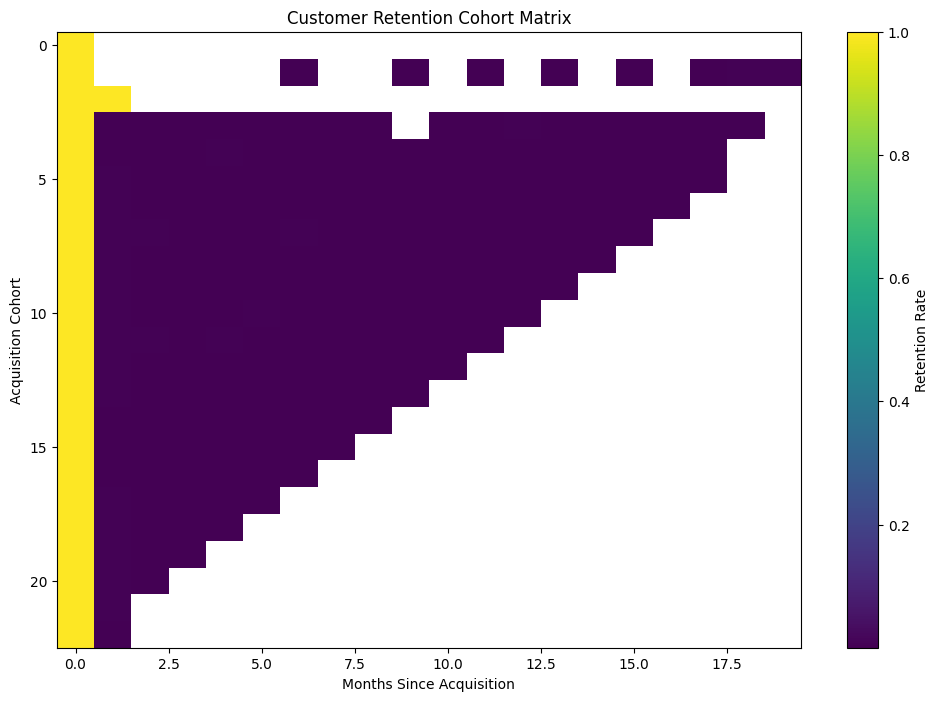

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.imshow(retention_matrix,aspect='auto')

plt.colorbar(label='Retention Rate')

plt.title('Customer Retention Cohort Matrix')

plt.xlabel('Months Since Acquisition')

plt.ylabel('Acquisition Cohort')

plt.show()

In [83]:
retention_matrix.iloc[:5, :6]

cohort_index,1,2,3,4,5,6
cohort_month,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN
2016-12,1.0,1.000000,NaN,NaN,NaN,NaN
2017-01,1.0,0.003979,0.002653,0.001326,0.003979,0.001326
2017-02,1.0,0.002346,0.002933,0.001173,0.004106,0.001173


In [84]:
retention_matrix.iloc[:10, :12].round(4)

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.0033,NaN,NaN,0.0033,NaN,0.0033
2016-12,1.0,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.0040,0.0027,0.0013,0.0040,0.0013,0.0040,0.0013,0.0013,NaN,0.0040,0.0013
2017-02,1.0,0.0023,0.0029,0.0012,0.0041,0.0012,0.0023,0.0018,0.0012,0.0018,0.0012,0.0029
2017-03,1.0,0.0050,0.0035,0.0039,0.0035,0.0015,0.0015,0.0031,0.0035,0.0008,0.0039,0.0012
2017-04,1.0,0.0060,0.0021,0.0017,0.0034,0.0026,0.0034,0.0030,0.0030,0.0017,0.0026,0.0009
2017-05,1.0,0.0048,0.0048,0.0039,0.0031,0.0034,0.0042,0.0014,0.0025,0.0028,0.0025,0.0034
2017-06,1.0,0.0048,0.0035,0.0039,0.0026,0.0039,0.0039,0.0022,0.0013,0.0022,0.0032,0.0035


In [85]:
master.to_csv(
    "olist_master_clean.csv",
    index=False
)

print("Master dataset saved.")

Master dataset saved.


In [86]:
retention_matrix.to_csv(
    "cohort_retention_matrix.csv"
)

print("Retention matrix saved.")

Retention matrix saved.


In [87]:
customer_features = (
    master.groupby('customer_unique_id')
    .agg(
        total_orders=('order_id', 'nunique'),
        first_purchase=('first_purchase_date', 'min'),
        repeat_customer=('repeat_customer_flag', 'max')
    )
    .reset_index()
)

customer_features.to_csv(
    "customer_features.csv",
    index=False
)

print("Customer features saved.")

Customer features saved.


In [88]:
print(master.shape)

print(master['order_id'].nunique())

print(master['customer_unique_id'].nunique())

print(master.duplicated().sum())

(112650, 48)
98666
95420
0


# Notebook 1 Summary: Data Cleaning & Feature Engineering

## Objective

The objective of this notebook was to transform Olist's raw relational marketplace data into a clean, analytics-ready dataset suitable for KPI reporting, experimentation, forecasting, customer segmentation, and machine learning applications.

Rather than immediately performing business analysis, the focus of this notebook was to establish a reliable data foundation by auditing data quality, resolving structural issues, engineering business-relevant features, and validating key assumptions before downstream statistical analyses.

---

## Data Quality Assessment

A comprehensive audit was conducted across all source tables, including orders, customers, products, sellers, reviews, payments, and geolocation data.

Several important findings emerged:

* Missing delivery timestamps were investigated rather than automatically imputed. Most missing values were operationally expected because the associated orders had not reached a delivered status. Only a small number of records represented genuine data-quality defects.
* Product catalog missingness was concentrated within a specific subset of products. A total of 610 products were missing all descriptive attributes simultaneously, indicating a catalog completeness issue rather than independent missing values.
* Review records were examined for duplicate submissions and reduced to a single review per order to ensure consistent customer-feedback analysis.
* Geolocation data contained a large number of duplicate postal-code observations and was aggregated to create a cleaner location reference table.

---

## Master Dataset Construction

The individual transactional tables were integrated into a single analytics-ready master dataset using appropriate primary-key and foreign-key relationships.

The final master dataset contains:

* **112,650 observations**
* **48 analytical features**
* **98,666 unique orders**
* **95,420 unique customers**
* **0 duplicate rows**

This consolidated dataset serves as the primary source for all subsequent analyses.

---

## Feature Engineering

Several groups of business-focused features were developed.

### Delivery Lifecycle Features

Delivery performance was decomposed into multiple operational stages:

* Approval Latency
* Carrier Handoff Time
* Carrier Transit Time
* Total Delivery Time
* Delivery Promise Gap
* On-Time Delivery Indicator

This decomposition enables identification of whether delays originate from payment approval, seller fulfillment, or logistics operations.

### Customer Features

Customer-level behavioral features were created, including:

* Customer Purchase Sequence
* First Purchase Date
* Repeat Customer Indicator
* Days Since First Purchase

These features provide the foundation for retention, cohort, segmentation, and lifetime-value analyses.

### Cohort Features

Monthly acquisition cohorts were constructed using customers' first purchase dates.

Additional cohort features include:

* Cohort Month
* Order Month
* Cohort Index

These variables will support retention analysis and customer lifecycle evaluation in later notebooks.

---

## Feature Validation

All engineered delivery metrics were validated before downstream use.

Key findings include:

* Approval latency and total delivery duration contained no negative values.
* A small number of carrier transit records contained impossible negative durations, representing isolated timestamp defects.
* Carrier handoff durations exhibited a larger set of negative values, indicating a combination of timestamp synchronization issues and data-quality anomalies.
* Invalid records were identified and documented to prevent contamination of later statistical analyses.

---

## Distribution Analysis

Delivery-related variables were assessed using descriptive statistics, percentile analysis, and skewness measurements.

Results showed strong positive skewness across delivery metrics, with skewness values exceeding 3.8 for all major delivery features.

The analysis revealed that:

* Most customers receive orders within a relatively predictable delivery window.
* A small subset of orders experiences extremely long delays.
* Mean delivery times are heavily influenced by these outliers.

Consequently, median-based measures and robust statistical methods will be emphasized throughout later experimentation and inference notebooks.

---

## Key Takeaways

The notebook established a trusted analytical foundation by:

1. Auditing and resolving data-quality issues.
2. Integrating multiple transactional tables into a unified analytical model.
3. Engineering delivery, customer, and cohort features.
4. Validating feature correctness through data-quality checks.
5. Identifying distributional properties relevant for future statistical testing.

The resulting datasets are now suitable for KPI development, experimentation frameworks, forecasting models, customer segmentation, and machine-learning applications.

---

## Outputs Generated

The following datasets will be used in subsequent notebooks:

* `olist_master_clean.csv`
* `customer_features.csv`
* `cohort_retention_matrix.csv`

These outputs form the foundation for **Notebook 2: Marketplace KPI Framework & Business Health Analysis**, where marketplace performance, customer behavior, delivery operations, and revenue trends will be evaluated from a business perspective.
